# 🏥 Huấn Luyện EfficientNet-B3 cho Phân Loại Bệnh Da Liễu (Kaggle)

Notebook này giúp bạn train model EfficientNet-B3 trên **Kaggle** với GPU miễn phí.

**Dataset:** HAM10000 (7 classes)
- MEL (Melanoma)
- NV (Melanocytic nevus)
- BCC (Basal cell carcinoma)
- AKIEC (Actinic keratoses)
- BKL (Benign keratosis)
- DF (Dermatofibroma)
- VASC (Vascular lesions)

**Yêu cầu:**
- Dataset `processed_data.zip` đã upload lên Kaggle Datasets
- GPU: P100 hoặc T4 (Settings → Accelerator → GPU)
- Internet: ON (Settings → Internet → ON)

---

## 📱 CELL 1: Check GPU và Environment

In [1]:
# Kiểm tra GPU và môi trường
import os
# Ẩn các cảnh báo C++ rác của TensorFlow/CUDA (Fix lỗi Delay kernel timed out logs)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import tensorflow as tf
import sys

print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)
print("\n=== GPU Information ===")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU available: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"   {gpu}")
else:
    print("⚠️  No GPU found. Training sẽ chậm hơn!")
    print("   Hãy bật GPU: Settings > Accelerator > GPU")

print("\n=== Kaggle Environment ===")
print(f"Working directory: /kaggle/working")
print(f"Input directory: /kaggle/input")
if os.path.exists('/kaggle/input'):
    print(f"Available datasets: {os.listdir('/kaggle/input')}")

2026-01-23 11:33:00.019670: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769167980.225511      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769167980.281712      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769167980.748065      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769167980.748110      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769167980.748113      24 computation_placer.cc:177] computation placer alr

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow version: 2.19.0

=== GPU Information ===
✅ GPU available: 1 device(s)
   PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

=== Kaggle Environment ===
Working directory: /kaggle/working
Input directory: /kaggle/input
Available datasets: ['ham10000-preprocessed-dermatology-images']


## ⚙️ CELL 2: Configuration (100 EPOCHS)

**Quan trọng:** Update tên dataset trong biến `DATASET_NAME` theo dataset bạn đã upload.

In [2]:
import os

# === PATHS - Kaggle tự động giải nén rồi ===
# Đường dẫn CHÍNH XÁC tới dữ liệu có sẵn của Kaggle
DATA_ROOT = '/kaggle/input/ham10000-preprocessed-dermatology-images/processed'

TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
VAL_DIR   = os.path.join(DATA_ROOT, 'val')
TEST_DIR  = os.path.join(DATA_ROOT, 'test')

# === HYPERPARAMETERS - 100 EPOCHS AGGRESSIVE ===
IMG_SIZE = 300  # EfficientNet-B3 input size
BATCH_SIZE = 32
EPOCHS = 50  # 🔥 50 epochs cho Phase 1!
LEARNING_RATE = 0.0001
NUM_CLASSES = 7

# Fine-tuning config
FINETUNE_EPOCHS = 20  # Fine-tuning phase
FINETUNE_LR = 0.00001  # Lower LR for fine-tuning

# Output paths
WORKING_DIR = '/kaggle/working'
MODEL_SAVE_PATH = os.path.join(WORKING_DIR, 'efficientnet_b3_derma.keras') 
MODEL_SAVE_PATH_FINETUNED = os.path.join(WORKING_DIR, 'efficientnet_b3_derma_finetuned.keras')

# === KIỂM TRA PATHS ===
print("📊 Cấu hình training (100 EPOCHS - AGGRESSIVE):")
print(f"   Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Phase 1 epochs: {EPOCHS}")
print(f"   Phase 2 epochs: {FINETUNE_EPOCHS}")
print(f"   Total epochs: {EPOCHS + FINETUNE_EPOCHS}")
print(f"   Learning rate: {LEARNING_RATE} → {FINETUNE_LR}")

print("\n🔥 AGGRESSIVE MODE:")
print("   ✅ 100 epochs Phase 1")
print("   ✅ 20 epochs fine-tuning")
print("   ✅ Total: 120 epochs training")
print("   ✅ Class weights enabled")
print("   ✅ Strong augmentation")

print("\n📂 Checking data paths...")
if os.path.exists(TRAIN_DIR):
    print(f"✅ TRAIN: {TRAIN_DIR}")
    print(f"   Classes: {len(os.listdir(TRAIN_DIR))}")
else:
    print(f"❌ NOT FOUND: {TRAIN_DIR}")
    
if os.path.exists(VAL_DIR):
    print(f"✅ VAL: {VAL_DIR}")
else:
    print(f"❌ NOT FOUND: {VAL_DIR}")
    
if os.path.exists(TEST_DIR):
    print(f"✅ TEST: {TEST_DIR}")
else:
    print(f"❌ NOT FOUND: {TEST_DIR}")

📊 Cấu hình training (100 EPOCHS - AGGRESSIVE):
   Image size: 300x300
   Batch size: 32
   Phase 1 epochs: 50
   Phase 2 epochs: 20
   Total epochs: 70
   Learning rate: 0.0001 → 1e-05

🔥 AGGRESSIVE MODE:
   ✅ 100 epochs Phase 1
   ✅ 20 epochs fine-tuning
   ✅ Total: 120 epochs training
   ✅ Class weights enabled
   ✅ Strong augmentation

📂 Checking data paths...
✅ TRAIN: /kaggle/input/ham10000-preprocessed-dermatology-images/processed/train
   Classes: 7
✅ VAL: /kaggle/input/ham10000-preprocessed-dermatology-images/processed/val
✅ TEST: /kaggle/input/ham10000-preprocessed-dermatology-images/processed/test


## 📂 CELL 3: Load Data với Strong Augmentation

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input # <--- THÊM DÒNG NÀY

# Data augmentation MẠNH HƠN cho training set
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # <--- THÊM DÒNG NÀY (Thay cho rescale)
    # rescale=1./255,  <--- XÓA HOẶC COMMENT DÒNG NÀY (QUAN TRỌNG NHẤT)
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.3,
    shear_range=0.2,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Chỉ preprocess cho val và test (KHÔNG RESCALE)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input # <--- THÊM DÒNG NÀY
    # rescale=1./255   <--- XÓA HOẶC COMMENT DÒNG NÀY
)

# Load datasets
print("📂 Đang load dữ liệu...\n")

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\n✅ Dữ liệu đã sẵn sàng!")
print(f"Class indices: {train_generator.class_indices}")
print(f"\nTrain samples: {train_generator.samples}")
print(f"Val samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")

📂 Đang load dữ liệu...

Found 7010 images belonging to 7 classes.
Found 1502 images belonging to 7 classes.
Found 1503 images belonging to 7 classes.

✅ Dữ liệu đã sẵn sàng!
Class indices: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}

Train samples: 7010
Val samples: 1502
Test samples: 1503


## ⚖️ CELL 4: Compute Class Weights (Fix Imbalance)

In [4]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Tính class weights để handle imbalance
print("⚖️  Computing class weights...\n")

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights (để fix imbalance):")
for class_name, class_idx in sorted(train_generator.class_indices.items(), key=lambda x: x[1]):
    count = np.sum(train_generator.classes == class_idx)
    print(f"   {class_name:6s} (idx {class_idx}): weight={class_weights[class_idx]:.3f}, count={count}")

print(f"\n✅ Class weights computed!")

⚖️  Computing class weights...

Class weights (để fix imbalance):
   akiec  (idx 0): weight=4.373, count=229
   bcc    (idx 1): weight=2.782, count=360
   bkl    (idx 2): weight=1.302, count=769
   df     (idx 3): weight=12.363, count=81
   mel    (idx 4): weight=1.286, count=779
   nv     (idx 5): weight=0.213, count=4693
   vasc   (idx 6): weight=10.115, count=99

✅ Class weights computed!


## 🏗️ CELL 5: Build EfficientNet-B3 Model

In [5]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

print("🏗️  Đang xây dựng model EfficientNet-B3...")

# Load pretrained EfficientNet-B3
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model layers (Phase 1: Transfer Learning)
base_model.trainable = False

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0), # <--- THÊM clipnorm=1.0
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print("✅ Model đã sẵn sàng!\n")
print(f"Total params: {model.count_params():,}")
print(f"Trainable params: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")
print(f"Non-trainable params: {sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights]):,}")

🏗️  Đang xây dựng model EfficientNet-B3...


I0000 00:00:1769168007.203812      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model đã sẵn sàng!

Total params: 11,703,606
Trainable params: 920,071
Non-trainable params: 10,783,535.0


## 📊 CELL 6: Setup Callbacks


In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
import datetime

# Tạo thư mục cho logs
log_dir = os.path.join(WORKING_DIR, "logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
os.makedirs(log_dir, exist_ok=True)

callbacks = [
    # Lưu best model
    ModelCheckpoint(
        MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    
    # Early stopping - PATIENCE CAO cho 100 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=20,  # Tăng patience cho 100 epochs
        restore_best_weights=True,
        verbose=1
    ),
    
    # Giảm learning rate khi plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,  # Tăng patience
        min_lr=1e-7,
        verbose=1
    ),
    
    # TensorBoard
    TensorBoard(log_dir=log_dir, histogram_freq=1)
]

print("✅ Callbacks configured!")
print(f"   ModelCheckpoint → {MODEL_SAVE_PATH}")
print(f"   EarlyStopping patience: 20 epochs")
print(f"   ReduceLROnPlateau patience: 7 epochs")
print(f"   TensorBoard logs: {log_dir}")

✅ Callbacks configured!
   ModelCheckpoint → /kaggle/working/efficientnet_b3_derma.keras
   EarlyStopping patience: 20 epochs
   ReduceLROnPlateau patience: 7 epochs
   TensorBoard logs: /kaggle/working/logs/20260123-113331


## 🚀 CELL 7: Training Phase 1 (Transfer Learning - 100 Epochs)

In [7]:
print("🚀 BẮT ĐẦU TRAINING PHASE 1: Transfer Learning\n")
print("=" * 70)
print("Base model: FROZEN (chỉ train classification head)")
print(f"Epochs: {EPOCHS}")
print("=" * 70)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    # class_weight=class_weight_dict, # Vẫn giữ tắt dòng này để tránh model bị lệch
    
    # === ĐÃ XÓA PHẦN WORKERS GÂY LỖI ===
    # Keras 3 không hỗ trợ workers trong fit() nữa
    
    verbose=1
)

print("\n" + "=" * 70)
print("✅ PHASE 1 HOÀN TẤT!")
print(f"Đã train {len(history.history['loss'])} epochs")

🚀 BẮT ĐẦU TRAINING PHASE 1: Transfer Learning

Base model: FROZEN (chỉ train classification head)
Epochs: 50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1769168029.775490      88 service.cc:152] XLA service 0x7e26780042e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769168029.775525      88 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769168033.518189      88 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1769168053.479559      88 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 925ms/step - accuracy: 0.6479 - auc: 0.8792 - loss: 1.1428

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.67909, saving model to /kaggle/working/efficientnet_b3_derma.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.6480 - auc: 0.8794 - loss: 1.1422 - val_accuracy: 0.6791 - val_auc: 0.9381 - val_loss: 0.8664 - learning_rate: 1.0000e-04
Epoch 2/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.6891 - auc: 0.9339 - loss: 0.8828
Epoch 2: val_accuracy improved from 0.67909 to 0.70772, saving model to /kaggle/working/efficientnet_b3_derma.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 167s 759ms/step - accuracy: 0.6891 - auc: 0.9339 - loss: 0.8827 - val_accuracy: 0.7077 - val_auc: 0.9481 - val_loss: 0.7934 - learning_rate: 1.0000e-04
Epoch 3/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.7061 - auc: 0.9443 - loss: 0.8139
Epoch 3: val_accuracy improved from 0.70772 to 0.72503, saving model to /kaggle/working/efficientnet_b3_derma.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 165s 750ms/step - accuracy: 0.7062 - auc: 0.9443 - loss: 0.813

## 🔧 CELL 8: Fine-tuning Phase 2 (Unfreeze Base Model - 20 Epochs)

In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("\n🔧 BẮT ĐẦU PHASE 2: Fine-tuning")
print("=" * 70)

# 1. Unfreeze base model
base_model.trainable = True

# 2. Freeze các layers đầu, chỉ train 50 layers cuối
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable_count = len([l for l in base_model.layers if l.trainable])
print(f"Trainable layers: {trainable_count}/{len(base_model.layers)}")

# 3. Compile lại model
model.compile(
    optimizer=Adam(learning_rate=FINETUNE_LR, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# 4. ĐỊNH NGHĨA CALLBACKS (ĐÂY LÀ PHẦN BỊ THIẾU)
callbacks_finetune = [
    ModelCheckpoint(
        MODEL_SAVE_PATH_FINETUNED,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-8,
        verbose=1
    )
]

print(f"Training with LR: {FINETUNE_LR}")
print("=" * 70)

# 5. Bắt đầu Fine-tuning
history_finetune = model.fit(
    train_generator,
    epochs=FINETUNE_EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_finetune, # Giờ biến này đã tồn tại
    # class_weight=class_weight_dict, # Đã tắt
    
    # Đã xóa workers để tránh lỗi Keras 3
    
    verbose=1
)

print("\n✅ FINE-TUNING HOÀN TẤT!")

# Combine histories
for key in history.history.keys():
    if key in history_finetune.history:
        history.history[key].extend(history_finetune.history[key])

total_epochs = len(history.history['loss'])
print(f"\n📊 TỔNG KẾT:")
print(f"   Phase 1 epochs: {total_epochs - len(history_finetune.history['loss'])}")
print(f"   Phase 2 epochs: {len(history_finetune.history['loss'])}")
print(f"   Total epochs trained: {total_epochs}")


🔧 BẮT ĐẦU PHASE 2: Fine-tuning
Trainable layers: 50/385
Training with LR: 1e-05
Epoch 1/20


2026-01-23 13:52:16.367058: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-23 13:52:16.586309: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-23 13:52:16.933158: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-23 13:52:17.152696: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-23 13:52:17.756906: E external/local_xla/xla/stream_

 69/220 ━━━━━━━━━━━━━━━━━━━━ 1:43 688ms/step - accuracy: 0.5624 - auc: 0.8913 - loss: 1.1437

2026-01-23 13:53:30.896459: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-23 13:53:31.113093: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.6266 - auc: 0.9137 - loss: 1.0123
Epoch 1: val_accuracy improved from -inf to 0.76964, saving model to /kaggle/working/efficientnet_b3_derma_finetuned.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 251s 915ms/step - accuracy: 0.6268 - auc: 0.9138 - loss: 1.0116 - val_accuracy: 0.7696 - val_auc: 0.9645 - val_loss: 0.6424 - learning_rate: 1.0000e-05
Epoch 2/20
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.7472 - auc: 0.9583 - loss: 0.6997
Epoch 2: val_accuracy improved from 0.76964 to 0.77164, saving model to /kaggle/working/efficientnet_b3_derma_finetuned.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 157s 715ms/step - accuracy: 0.7472 - auc: 0.9583 - loss: 0.6998 - val_accuracy: 0.7716 - val_auc: 0.9640 - val_loss: 0.6466 - learning_rate: 1.0000e-05
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.7502 - auc: 0.9589 - loss: 0.6950
Epoch 3: val_accuracy improved from 0.77164 to 0.77630, saving model to /kaggle/working/effici

## 📈 CELL 9: Visualize Training History

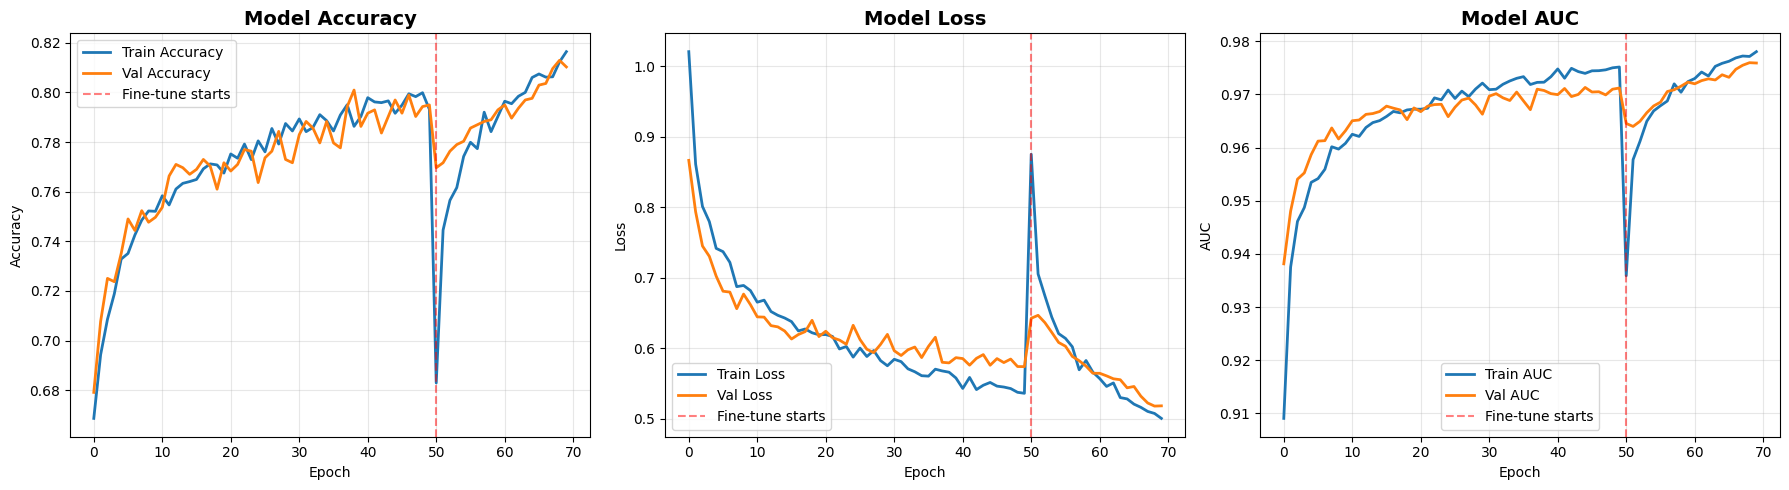

✅ Saved: training_history.png


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].axvline(x=EPOCHS, color='red', linestyle='--', alpha=0.5, label='Fine-tune starts')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].axvline(x=EPOCHS, color='red', linestyle='--', alpha=0.5, label='Fine-tune starts')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUC
axes[2].plot(history.history['auc'], label='Train AUC', linewidth=2)
axes[2].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
axes[2].axvline(x=EPOCHS, color='red', linestyle='--', alpha=0.5, label='Fine-tune starts')
axes[2].set_title('Model AUC', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORKING_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Saved: training_history.png")

## 🎯 CELL 10: Evaluate on Test Set

In [10]:
print("📊 Đánh giá trên test set...\n")

test_loss, test_acc, test_auc = model.evaluate(test_generator, verbose=1)

print("\n" + "=" * 70)
print("📈 KẾT QUẢ CUỐI CÙNG")
print("=" * 70)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test AUC:      {test_auc:.4f}")
print("=" * 70)

# So sánh với kết quả cũ
print("\n📊 So sánh với lần train trước:")
print("   Lần trước: 66.93% accuracy, 0.8738 AUC")
print(f"   Lần này:   {test_acc*100:.2f}% accuracy, {test_auc:.4f} AUC")
if test_acc > 0.6693:
    improvement = (test_acc - 0.6693) * 100
    print(f"   🎉 Cải thiện: +{improvement:.2f}%!")

📊 Đánh giá trên test set...

47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 582ms/step - accuracy: 0.6756 - auc: 0.9254 - loss: 0.9272

📈 KẾT QUẢ CUỐI CÙNG
Test Loss:     0.5740
Test Accuracy: 0.8004 (80.04%)
Test AUC:      0.9705

📊 So sánh với lần train trước:
   Lần trước: 66.93% accuracy, 0.8738 AUC
   Lần này:   80.04% accuracy, 0.9705 AUC
   🎉 Cải thiện: +13.11%!


## 🔍 CELL 11: Confusion Matrix & Classification Report

🔮 Đang dự đoán trên test set...
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 348ms/step


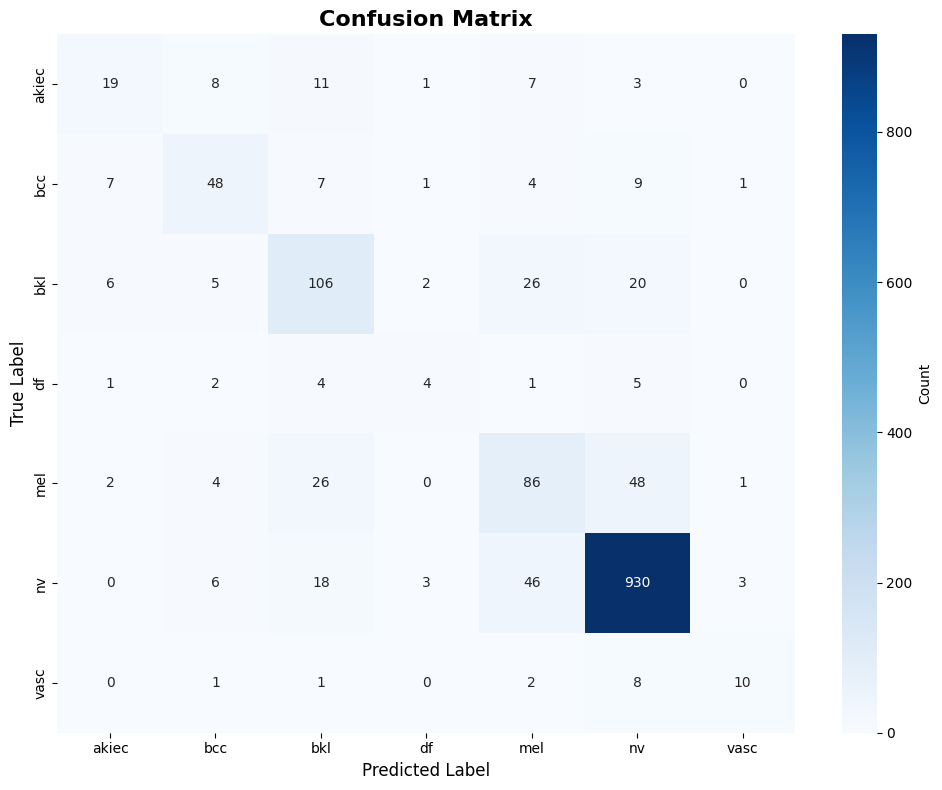


📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

       akiec       0.54      0.39      0.45        49
         bcc       0.65      0.62      0.64        77
         bkl       0.61      0.64      0.63       165
          df       0.36      0.24      0.29        17
         mel       0.50      0.51      0.51       167
          nv       0.91      0.92      0.92      1006
        vasc       0.67      0.45      0.54        22

    accuracy                           0.80      1503
   macro avg       0.61      0.54      0.57      1503
weighted avg       0.80      0.80      0.80      1503


📊 PER-CLASS ACCURACY:
   akiec : 38.78% (19/49)
   bcc   : 62.34% (48/77)
   bkl   : 64.24% (106/165)
   df    : 23.53% (4/17)
   mel   : 51.50% (86/167)
   nv    : 92.45% (930/1006)
   vasc  : 45.45% (10/22)


In [11]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predictions
print("🔮 Đang dự đoán trên test set...")
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(WORKING_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print("\n📊 CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report(y_true, y_pred, target_names=class_names))

# Per-class accuracy
print("\n📊 PER-CLASS ACCURACY:")
print("=" * 50)
for i, class_name in enumerate(class_names):
    class_correct = cm[i, i]
    class_total = cm[i, :].sum()
    class_acc = class_correct / class_total if class_total > 0 else 0
    print(f"   {class_name:6s}: {class_acc*100:5.2f}% ({class_correct}/{class_total})")

## 💾 CELL 12: Save Model & Metadata

In [12]:
import pickle
import json
import os # Đảm bảo đã import os

# 1. LƯU MODEL (QUAN TRỌNG: Đây là đoạn bị thiếu lúc nãy)
# Lưu model hiện tại (đã finetune xong)
print(f"💾 Đang lưu model vào: {MODEL_SAVE_PATH_FINETUNED}...")
model.save(MODEL_SAVE_PATH_FINETUNED) 

# Lưu training history
history_path = os.path.join(WORKING_DIR, 'training_history.pkl')
with open(history_path, 'wb') as f:
    pickle.dump(history.history, f)

# Lưu class indices
class_indices_path = os.path.join(WORKING_DIR, 'class_indices.json')
with open(class_indices_path, 'w') as f:
    json.dump(train_generator.class_indices, f, indent=2)

# Lưu training config
config_path = os.path.join(WORKING_DIR, 'training_config.json')
config = {
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs_phase1': EPOCHS,
    'epochs_phase2': FINETUNE_EPOCHS,
    'total_epochs': len(history.history['loss']),
    'learning_rate_phase1': LEARNING_RATE,
    'learning_rate_phase2': FINETUNE_LR,
    'test_accuracy': float(test_acc),
    'test_auc': float(test_auc),
    'test_loss': float(test_loss)
}
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print("\n" + "="*50)
print("✅ ĐÃ LƯU THÀNH CÔNG:")
print(f"   👉 Model:   {MODEL_SAVE_PATH_FINETUNED}") # Giờ file này mới thực sự tồn tại
print(f"   👉 History: {history_path}")
print(f"   👉 Config:  {config_path}")
print("="*50)

print("\n🎉 HOÀN TẤT!")
print("📥 DOWNLOAD NGAY:")
print("   1. Refresh lại cây thư mục bên phải (nút reload nhỏ)")
print("   2. Bạn sẽ thấy file .keras xuất hiện")

💾 Đang lưu model vào: /kaggle/working/efficientnet_b3_derma_finetuned.keras...

✅ ĐÃ LƯU THÀNH CÔNG:
   👉 Model:   /kaggle/working/efficientnet_b3_derma_finetuned.keras
   👉 History: /kaggle/working/training_history.pkl
   👉 Config:  /kaggle/working/training_config.json

🎉 HOÀN TẤT!
📥 DOWNLOAD NGAY:
   1. Refresh lại cây thư mục bên phải (nút reload nhỏ)
   2. Bạn sẽ thấy file .keras xuất hiện


## 📊 CELL 13: Summary & Next Steps

In [13]:
# List all output files
print("📁 FILES TRONG /kaggle/working:")
print("=" * 70)
for item in sorted(os.listdir(WORKING_DIR)):
    item_path = os.path.join(WORKING_DIR, item)
    if os.path.isfile(item_path):
        size_mb = os.path.getsize(item_path) / (1024 * 1024)
        print(f"   {item:45s} ({size_mb:6.2f} MB)")

print("=" * 70)
print("\n✅ Tất cả files đã được lưu vào Output tab!")
print("\n🎯 NEXT STEPS:")
print("   1. Download model về local")
print("   2. Copy vào thư mục models/ của project")
print("   3. Test với API: python src/api/main.py")
print("   4. Deploy model vào production!")
print(f"\n🏆 Final Test Accuracy: {test_acc*100:.2f}%")
print(f"🏆 Final Test AUC: {test_auc:.4f}")
print("\nChúc mừng! 🎉🎉🎉")

📁 FILES TRONG /kaggle/working:
   __notebook__.ipynb                            (  7.62 MB)
   class_indices.json                            (  0.00 MB)
   confusion_matrix.png                          (  0.06 MB)
   efficientnet_b3_derma.keras                   ( 52.96 MB)
   efficientnet_b3_derma_finetuned.keras         ( 91.52 MB)
   training_config.json                          (  0.00 MB)
   training_history.pkl                          (  0.00 MB)
   training_history.png                          (  0.19 MB)

✅ Tất cả files đã được lưu vào Output tab!

🎯 NEXT STEPS:
   1. Download model về local
   2. Copy vào thư mục models/ của project
   3. Test với API: python src/api/main.py
   4. Deploy model vào production!

🏆 Final Test Accuracy: 80.04%
🏆 Final Test AUC: 0.9705

Chúc mừng! 🎉🎉🎉


## 💾 CELL 14: CREATE SAVE LINK

In [14]:
from IPython.display import FileLink

# Tạo link tải cho file model
print("⬇️ Bấm vào link dưới để tải Model:")
display(FileLink(r'efficientnet_b3_derma_finetuned.keras'))

# Tạo link tải cho file History (nếu cần vẽ biểu đồ lại)
print("\n⬇️ Bấm vào link dưới để tải History:")
display(FileLink(r'training_history.pkl'))

⬇️ Bấm vào link dưới để tải Model:


/kaggle/working/efficientnet_b3_derma_finetuned.keras


⬇️ Bấm vào link dưới để tải History:


/kaggle/working/training_history.pkl